# Conway's Game of Life — Analysis Notebook

Phase 6 analysis of exported dashboard CSVs from `analysis/data/`.

**Pipeline:**
1. Load & validate CSVs (schema check, filename vs `run_id` match, duplicate drop)
2. Data quality summary
3. Exploratory plots
4. Distribution-free statistics (Spearman, bootstrap CI, Mann-Whitney)
5. Classification CV (Decision Tree, Logistic Regression, k-NN)
6. Regression CV (quadratic density → generations)


In [18]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
warnings.simplefilter('default')  # keep warnings visible — suppressing hides model failures


## 1. Load & Validate CSVs

Checks performed per file:
- Required columns present
- `run_id` inside file matches filename stem
- Numeric coercion with NaN flagging
- `endReason` normalisation (lowercase, underscore)

After concat:
- Duplicate `(run_id, session)` pairs dropped (keep first)
- `densityBand` assigned — `edge_30_40` is the hypothesis zone


In [19]:
data_dir = Path('data')
files = sorted(data_dir.glob('*.csv'))

if not files:
    raise FileNotFoundError('No CSV files found in analysis/data/. Export from the dashboard first.')

required_columns = {
    'run_id', 'session', 'density', 'peakPop', 'avgEntropy',
    'avgPBirth', 'avgPDeath', 'generations', 'endReason', 'autocorr'
}
numeric_columns = ['session', 'density', 'peakPop', 'avgEntropy', 'avgPBirth', 'avgPDeath', 'generations', 'autocorr']
reason_map = {'stagnant': 0, 'died': 1, 'max_gens': 2}

frames = []
for path in files:
    frame = pd.read_csv(path)
    missing_columns = required_columns.difference(frame.columns)
    if missing_columns:
        raise ValueError(f'{path.name} is missing expected columns: {sorted(missing_columns)}')
    frame['source_file'] = path.name
    frame['expected_run_id'] = path.stem
    frames.append(frame)

raw_df = pd.concat(frames, ignore_index=True)
raw_row_count = len(raw_df)

raw_df['run_id'] = raw_df['run_id'].astype(str).str.strip()
raw_df['endReason'] = (
    raw_df['endReason']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

for column in numeric_columns:
    raw_df[column] = pd.to_numeric(raw_df[column], errors='coerce')

invalid_reason_mask = ~raw_df['endReason'].isin(reason_map)
invalid_numeric_mask = raw_df[numeric_columns].isna().any(axis=1)
filename_mismatch_mask = raw_df['run_id'] != raw_df['expected_run_id']
duplicate_mask = raw_df.duplicated(subset=['run_id', 'session'], keep='first')

bad_row_count = int((invalid_reason_mask | invalid_numeric_mask).sum())
duplicate_count = int(duplicate_mask.sum())
filename_mismatch_count = int(filename_mismatch_mask.sum())

df = raw_df.loc[~(invalid_reason_mask | invalid_numeric_mask | duplicate_mask)].copy()
df['endReasonCode'] = df['endReason'].map(reason_map).astype(int)

# Bin boundaries offset by 0.5 so integer densities map cleanly.
# edge_30_40 is the hypothesis zone (30–40% expected to maximise lifespan).
df['densityBand'] = pd.cut(
    df['density'],
    bins=[14.5, 29.5, 40.5, 55.5],
    labels=['low_15_29', 'edge_30_40', 'high_41_55'],
    include_lowest=True,
)


## 2. Data Quality Summary

Always run this before any analysis. Check:
- Rows removed vs loaded
- Density coverage (gaps in the 15–55 range mean missing experimental conditions)
- Filename mismatches (indicates export ID bug from dashboard)


In [20]:
quality_summary = pd.DataFrame({
    'metric': [
        'files_loaded',
        'rows_loaded',
        'rows_after_cleaning',
        'invalid_reason_or_numeric_rows_removed',
        'duplicate_run_session_rows_removed',
        'filename_run_id_mismatches',
    ],
    'value': [
        len(files),
        raw_row_count,
        len(df),
        bad_row_count,
        duplicate_count,
        filename_mismatch_count,
    ],
})

display(quality_summary)

print('Rows per file:')
display(df.groupby('source_file').size().rename('sessions').to_frame())

print('Rows per run_id:')
display(
    df.groupby('run_id')
    .agg(
        sessions=('session', 'count'),
        density_min=('density', 'min'),
        density_max=('density', 'max'),
    )
    .sort_index()
)

print('Sessions per density:')
display(df['density'].value_counts().sort_index().rename_axis('density').to_frame('sessions'))

if filename_mismatch_count:
    print('Filename mismatches detected:')
    display(
        raw_df.loc[filename_mismatch_mask, ['source_file', 'expected_run_id', 'run_id']]
        .drop_duplicates()
        .sort_values(['source_file', 'run_id'])
    )


,metric,value
0,files_loaded,4
1,rows_loaded,75
2,rows_after_cleaning,75
3,invalid_reason_or_numeric_rows_removed,0
4,duplicate_run_session_rows_removed,0
5,filename_run_id_mismatches,0


Rows per file:


,sessions
source_file,
run1_2026_04_01.csv,15
run2_2026_04_01.csv,15
run3_2026_04_01.csv,15
run4_2026_04_01.csv,30


Rows per run_id:


,sessions,density_min,density_max
run_id,,,
run1_2026_04_01,15,15,35
run2_2026_04_01,15,28,44
run3_2026_04_01,15,38,55
run4_2026_04_01,30,29,55


Sessions per density:


,sessions
density,
15,3
19,3
24,3
28,3
29,1
30,8
31,2
32,1
35,9


## 3. Exploratory Plots

Four scatter plots coloured by `endReason`, plus a box plot of generations by density band.
Look for:
- Entropy separation between outcome classes
- Any non-linear density → generations trend
- Whether edge_30_40 visually dominates the generation count


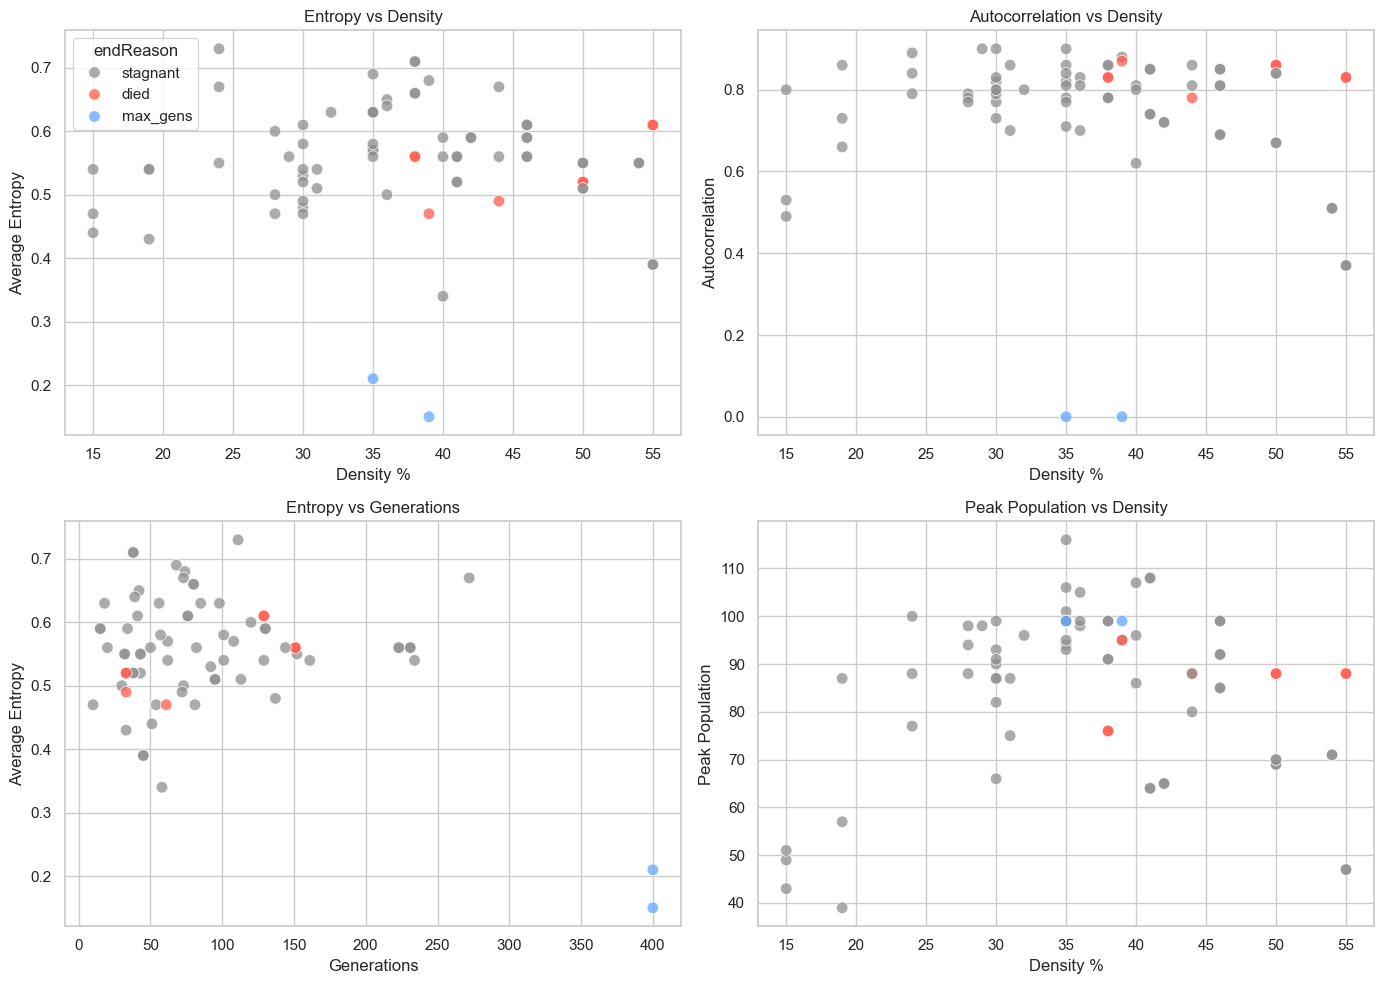

/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


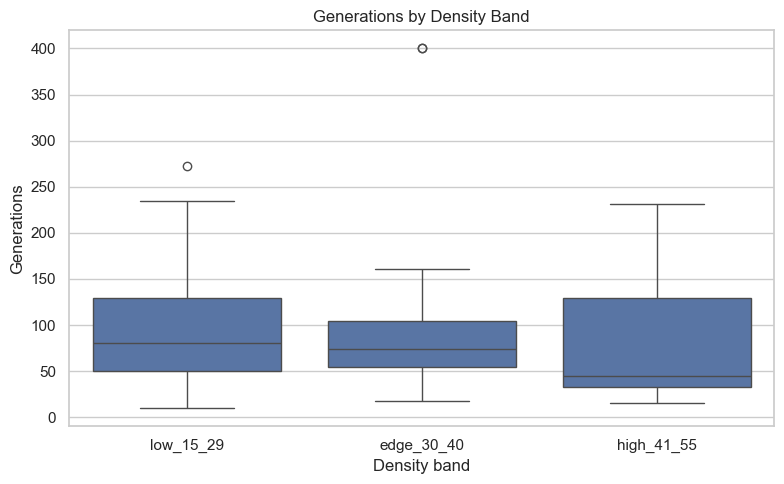

In [21]:
hue_order = ['stagnant', 'died', 'max_gens']
palette = {'stagnant': '#8f8f8f', 'died': '#ff5b4d', 'max_gens': '#5fa8ff'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x='density', y='avgEntropy', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, ax=axes[0, 0])
axes[0, 0].set(title='Entropy vs Density', xlabel='Density %', ylabel='Average Entropy')

sns.scatterplot(data=df, x='density', y='autocorr', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, legend=False, ax=axes[0, 1])
axes[0, 1].set(title='Autocorrelation vs Density', xlabel='Density %', ylabel='Autocorrelation')

sns.scatterplot(data=df, x='generations', y='avgEntropy', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, legend=False, ax=axes[1, 0])
axes[1, 0].set(title='Entropy vs Generations', xlabel='Generations', ylabel='Average Entropy')

sns.scatterplot(data=df, x='density', y='peakPop', hue='endReason',
                hue_order=hue_order, palette=palette, s=70, alpha=0.75, legend=False, ax=axes[1, 1])
axes[1, 1].set(title='Peak Population vs Density', xlabel='Density %', ylabel='Peak Population')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='densityBand', y='generations',
            order=['low_15_29', 'edge_30_40', 'high_41_55'])
plt.title('Generations by Density Band')
plt.xlabel('Density band')
plt.ylabel('Generations')
plt.tight_layout()
plt.show()


## 4. Distribution-Free Statistics

All methods here are non-parametric — no normality assumption.
Generation counts are right-skewed (most runs die quickly, a few survive long),
so parametric tests (t-test, Pearson) would give misleading p-values on small samples.

- **Bootstrap CI** — estimates sampling distribution empirically from the data itself
- **Spearman ρ** — rank correlation, robust to outliers and skew
- **Mann-Whitney U** — tests whether edge_30_40 has a different generation distribution vs outer bands


In [22]:
def bootstrap_ci(values, func=np.median, n_boot=2000, seed=42):
    values = np.asarray(values, dtype=float)
    if len(values) < 5:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boot_stats = [func(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    low, high = np.percentile(boot_stats, [2.5, 97.5])
    return float(low), float(high)


band_summary = (
    df.groupby('densityBand', observed=False)
    .agg(
        sessions=('session', 'count'),
        mean_generations=('generations', 'mean'),
        median_generations=('generations', 'median'),
        mean_entropy=('avgEntropy', 'mean'),
        mean_autocorr=('autocorr', 'mean'),
    )
    .round(3)
)
print('Density band summary:')
display(band_summary)

for band in ['low_15_29', 'edge_30_40', 'high_41_55']:
    values = df.loc[df['densityBand'] == band, 'generations'].dropna()
    if len(values) >= 5:
        low_ci, high_ci = bootstrap_ci(values, func=np.median)
        print(f'{band}: median generations {np.median(values):.1f} '
              f'(95% bootstrap CI {low_ci:.1f} to {high_ci:.1f}, n={len(values)})')
    else:
        print(f'{band}: need at least 5 samples for bootstrap CI (n={len(values)})')

if len(df) >= 8:
    rho, p = stats.spearmanr(df['density'], df['autocorr'])
    print(f'\nSpearman density/autocorr:   rho={rho:.3f}, p={p:.4f}')
    rho, p = stats.spearmanr(df['density'], df['generations'])
    print(f'Spearman density/generations: rho={rho:.3f}, p={p:.4f}')
else:
    print('Need at least 8 rows for Spearman correlation.')

edge_generations = df.loc[df['densityBand'] == 'edge_30_40', 'generations'].dropna()
outer_generations = df.loc[df['densityBand'] != 'edge_30_40', 'generations'].dropna()

print()
if len(edge_generations) >= 5 and len(outer_generations) >= 5:
    stat, p = stats.mannwhitneyu(edge_generations, outer_generations, alternative='two-sided')
    print(f'Mann-Whitney edge vs outer generations: U={stat:.1f}, p={p:.4f}')
    verdict = 'SUPPORTED' if p < 0.05 else 'NOT supported'
    print(f'Hypothesis (edge 30-40% has longer lifespan): {verdict} (alpha=0.05)')
else:
    print('Need at least 5 edge and 5 outer samples for Mann-Whitney comparison.')


Density band summary:


,sessions,mean_generations,median_generations,mean_entropy,mean_autocorr
densityBand,,,,,
low_15_29,13,102.692,81.0,0.542,0.756
edge_30_40,35,97.486,74.0,0.555,0.759
high_41_55,27,85.407,45.0,0.550,0.738


low_15_29: median generations 81.0 (95% bootstrap CI 50.0 to 129.0, n=13)
edge_30_40: median generations 74.0 (95% bootstrap CI 58.0 to 98.0, n=35)
high_41_55: median generations 45.0 (95% bootstrap CI 38.0 to 95.0, n=27)

Spearman density/autocorr:   rho=-0.050, p=0.6721
Spearman density/generations: rho=-0.127, p=0.2766

Mann-Whitney edge vs outer generations: U=782.0, p=0.3866
Hypothesis (edge 30-40% has longer lifespan): NOT supported (alpha=0.05)


## 5. Classification & Regression

**Classification** — predict `endReason` from `[density, avgEntropy, avgPBirth, avgPDeath, autocorr]`.
Uses stratified k-fold so each fold preserves class ratios.
Guards: ≥20 rows total, ≥4 samples per class.

**Regression** — predict `generations` from `density` using a quadratic fit.
Guards: ≥16 rows, ≥2 folds with multi-row test sets.
Reports negative-R² fold count — a flag that the model is worse than the mean baseline on those folds.


Need ≥20 rows and ≥4 samples per end-reason class for reliable classification CV.

Regression: 5-fold CV, ~15 test rows/fold
Density-only quadratic regression: R² -0.156 ± 0.241,  MAE 56.75 ± 7.77

Per-density-band MAE (quadratic fit):


,mean_ae,median_ae,n
densityBand,,,
low_15_29,59.14,52.09,13
edge_30_40,52.39,40.14,35
high_41_55,56.22,48.57,27


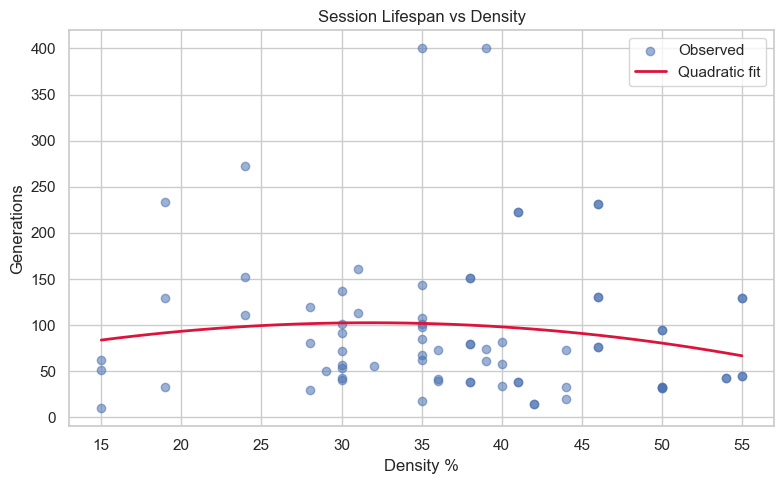

In [23]:
feature_columns = ['density', 'avgEntropy', 'avgPBirth', 'avgPDeath', 'autocorr']
X = df[feature_columns]
y = df['endReason']

class_counts = y.value_counts()
min_class_count = int(class_counts.min()) if not class_counts.empty else 0

if len(class_counts) >= 2 and min_class_count >= 4 and len(df) >= 20:
    n_splits = min(5, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    max_test_size = int(np.ceil(len(df) / n_splits))
    min_train_size = len(df) - max_test_size
    knn_k = min(5, max(1, min_train_size))
    min_test_fold = int(np.floor(len(df) / n_splits))

    print(f'Classification: {n_splits}-fold stratified CV '
          f'(~{min_test_fold}–{max_test_size} test rows/fold, '
          f'{min_train_size} min train rows, k-NN k={knn_k})')
    print('Class counts:')
    display(class_counts.rename_axis('endReason').to_frame('count'))

    models = [
        ('Decision Tree',      DecisionTreeClassifier(max_depth=4, random_state=42)),
        ('Logistic Regression', Pipeline([
            ('scale', StandardScaler()),
            ('clf',   LogisticRegression(max_iter=2000)),
        ])),
        ('k-NN', Pipeline([
            ('scale', StandardScaler()),
            ('clf',   KNeighborsClassifier(n_neighbors=knn_k)),
        ])),
    ]

    for name, model in models:
        try:
            scores = cross_validate(
                model, X, y, cv=cv,
                scoring={'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy'},
                error_score='raise',
            )
            print(
                f"{name}: accuracy {scores['test_accuracy'].mean():.3f}"
                f" ± {scores['test_accuracy'].std():.3f},  "
                f"balanced accuracy {scores['test_balanced_accuracy'].mean():.3f}"
                f" ± {scores['test_balanced_accuracy'].std():.3f}"
            )
        except Exception as exc:
            print(f'{name}: CV failed — {exc}')
else:
    print('Need ≥20 rows and ≥4 samples per end-reason class for reliable classification CV.')

# ── Regression ───────────────────────────────────────────────────────────────
print()
if len(df) >= 16:
    reg_X = df[['density']]
    reg_y = df['generations']
    reg_splits = min(5, len(df) // 4)

    if reg_splits >= 2:
        reg_cv = KFold(n_splits=reg_splits, shuffle=True, random_state=42)
        poly_model = Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('reg',  LinearRegression()),
        ])

        reg_scores = cross_validate(
            poly_model, reg_X, reg_y, cv=reg_cv,
            scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
            error_score='raise',
        )

        reg_test_size = int(np.ceil(len(df) / reg_splits))
        print(f'Regression: {reg_splits}-fold CV, ~{reg_test_size} test rows/fold')

        neg_r2_folds = (reg_scores['test_r2'] < 0).sum()
        if neg_r2_folds:
            print(f'  Warning: {neg_r2_folds}/{reg_splits} folds have negative R² '
                  f'(model worse than mean baseline on those folds)')

        print(
            f"Density-only quadratic regression: "
            f"R² {reg_scores['test_r2'].mean():.3f} ± {reg_scores['test_r2'].std():.3f},  "
            f"MAE {-reg_scores['test_mae'].mean():.2f} ± {reg_scores['test_mae'].std():.2f}"
        )

        poly_model.fit(reg_X, reg_y)
        density_range = pd.DataFrame({'density': np.arange(15, 56)})
        y_pred = poly_model.predict(density_range)

        # Per-band MAE — shows whether model error concentrates in the hypothesis zone
        df_pred = df[['density', 'generations', 'densityBand']].copy()
        df_pred['predicted'] = poly_model.predict(df[['density']])
        df_pred['abs_error'] = (df_pred['generations'] - df_pred['predicted']).abs()
        print('\nPer-density-band MAE (quadratic fit):')
        display(
            df_pred.groupby('densityBand', observed=False)['abs_error']
            .agg(['mean', 'median', 'count'])
            .rename(columns={'mean': 'mean_ae', 'median': 'median_ae', 'count': 'n'})
            .round(2)
        )

        plt.figure(figsize=(8, 5))
        plt.scatter(df['density'], df['generations'], alpha=0.55, label='Observed')
        plt.plot(density_range['density'], y_pred,
                 color='crimson', linewidth=2, label='Quadratic fit')
        plt.xlabel('Density %')
        plt.ylabel('Generations')
        plt.title('Session Lifespan vs Density')
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('Need enough rows to form regression folds with multi-row test sets.')
else:
    print('Need ≥16 rows for regression CV with stable multi-row test folds.')


## Next Steps

- Keep export filenames in the format `runX_YYYY_MM_DD` so the filename and `run_id` continue to match.
- Treat each export batch as an independent replicate. Prefer multiple smaller batches over one large block at a single density.
- Keep `maxGens` and `hashHistory` fixed for one training campaign. If you change them, start a new cohort of exports.
- Once the dataset is large enough, save selected trained models into `analysis/models/` with `joblib` and record the feature set and CV scores beside them.
- Target ≥100 sessions before drawing strong conclusions — generation counts are right-skewed and CLT convergence requires more data than intuition suggests.
